# Tugas Praktik Pertemuan 6 — Predictive Modeling Konsumsi Listrik

Notebook ini mengerjakan tugas **Predictive Modeling Konsumsi Listrik** menggunakan dataset IoT.

Tahapan yang dilakukan:

1. Membaca dan memahami dataset.
2. Membersihkan **missing values** dan **outlier**.
3. Membuat fitur `jam` dan `hari` dari `timestamp`.
4. Melakukan **chronological train-test split 80:20**.
5. Melatih model **Linear Regression**.
6. Melatih model **Decision Tree Regressor** dengan `max_depth=5`.
7. Mengevaluasi kedua model menggunakan **MAE, MSE, RMSE, dan R²**.
8. Membandingkan performa model dan memeriksa indikasi overfitting.
9. Memvisualisasikan nilai aktual dan hasil prediksi.
10. Menyusun kesimpulan.

> **Catatan:** Pastikan file `data_sensor_iot_pertemuan_5.csv` berada pada folder kerja yang sama dengan notebook ini ketika dijalankan di Jupyter/Google Colab.


## Cell 1 — Import library

Cell ini mengimpor library yang dibutuhkan selama proses analisis.

- `pandas` digunakan untuk membaca dan memanipulasi data.
- `numpy` digunakan untuk operasi numerik, terutama menghitung RMSE.
- `matplotlib.pyplot` digunakan untuk membuat visualisasi.
- `LinearRegression` dan `DecisionTreeRegressor` merupakan dua algoritma regresi yang akan dibandingkan.
- `mean_absolute_error`, `mean_squared_error`, dan `r2_score` digunakan untuk mengevaluasi performa model.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Cell 2 — Membaca dataset

Dataset dibaca menggunakan `pd.read_csv()`.

File menggunakan tanda titik koma (`;`) sebagai pemisah kolom, sehingga parameter `sep=';'` harus diberikan. Setelah data berhasil dibaca, lima baris pertama ditampilkan untuk memastikan struktur data sudah benar.


In [2]:
df = pd.read_csv(
    'data_sensor_iot_pertemuan_5.csv',
    sep=';'
)

df.head()

,timestamp,suhu,kelembaban,konsumsi_listrik
0,01/01/2025 00:00,20.75,71.37,0.5
1,01/01/2025 01:00,19.96,73.11,0.5
2,01/01/2025 02:00,21.64,70.89,0.5
3,01/01/2025 03:00,23.75,71.33,0.5
4,01/01/2025 04:00,22.15,75.87,0.5


## Cell 3 — Pemeriksaan awal dataset

Cell ini digunakan untuk memahami kondisi awal data sebelum dibersihkan.

Informasi yang diperiksa meliputi:

- jumlah baris dan kolom;
- nama dan tipe data setiap kolom;
- jumlah nilai kosong pada setiap kolom;
- jumlah baris duplikat.

Pada dataset ini terdapat **10.000 baris dan 4 kolom**. Kolom `suhu` memiliki **30 missing values**, sedangkan `konsumsi_listrik` terbaca sebagai tipe `object` karena format angkanya tidak konsisten.


In [3]:
print("Ukuran dataset:", df.shape)

print("\nTipe data:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nJumlah baris duplikat:")
print(df.duplicated().sum())

Ukuran dataset: (10000, 4)

Tipe data:
timestamp            object
suhu                float64
kelembaban          float64
konsumsi_listrik     object
dtype: object

Missing values:
timestamp            0
suhu                30
kelembaban           0
konsumsi_listrik     0
dtype: int64

Jumlah baris duplikat:
0


## Cell 4 — Konversi `timestamp` dan normalisasi `konsumsi_listrik`

Kolom `timestamp` masih berupa teks, sehingga dikonversi menjadi tipe `datetime`. Parameter `dayfirst=True` digunakan karena format tanggal pada dataset adalah **hari/bulan/tahun**.

Kolom `konsumsi_listrik` juga perlu dibersihkan karena memiliki dua pola penulisan, misalnya:

- `0.961`
- `3125,00`

Jika `3125,00` dibaca secara literal sebagai 3125, skalanya menjadi tidak konsisten dengan sebagian besar data lainnya. Dalam notebook ini nilai tersebut dinormalisasi menjadi **3.125** dengan mengganti koma menjadi titik lalu membaginya dengan 1000.

Asumsi ini dibuat berdasarkan pola internal dataset. Jika dosen memberikan aturan konversi yang berbeda, fungsi `parse_konsumsi()` pada cell ini adalah bagian yang perlu disesuaikan.


In [4]:
df['timestamp'] = pd.to_datetime(
    df['timestamp'],
    dayfirst=True
)

def parse_konsumsi(value):
    value = str(value).strip()

    if ',' in value:
        # Contoh: "3125,00" -> 3125.00 -> 3.125
        return float(value.replace(',', '.')) / 1000

    return float(value)

df['konsumsi_listrik'] = df['konsumsi_listrik'].apply(parse_konsumsi)

print(df.head(15))
print("\nTipe data setelah konversi:")
print(df.dtypes)

print("\nStatistik konsumsi listrik:")
print(df['konsumsi_listrik'].describe())

             timestamp   suhu  kelembaban  konsumsi_listrik
0  2025-01-01 00:00:00  20.75       71.37             0.500
1  2025-01-01 01:00:00  19.96       73.11             0.500
2  2025-01-01 02:00:00  21.64       70.89             0.500
3  2025-01-01 03:00:00  23.75       71.33             0.500
4  2025-01-01 04:00:00  22.15       75.87             0.500
5  2025-01-01 05:00:00  23.35       69.00             0.500
6  2025-01-01 06:00:00  27.37       71.11             0.961
7  2025-01-01 07:00:00  27.45       65.70             3.125
8  2025-01-01 08:00:00  26.80       66.02             2.423
9  2025-01-01 09:00:00  29.35       68.98             4.776
10 2025-01-01 10:00:00  28.64       69.86             4.242
11 2025-01-01 11:00:00  29.13       69.25             4.524
12 2025-01-01 12:00:00  30.36       61.76             4.615
13 2025-01-01 13:00:00  26.96       67.03             3.514
14 2025-01-01 14:00:00  26.74       71.07             4.284

Tipe data setelah konversi:
timestamp  

## Cell 5 — Menangani missing value

Hasil pemeriksaan awal menunjukkan bahwa kolom `suhu` memiliki 30 nilai kosong.

Missing value pada `suhu` diisi menggunakan **median**. Median dipilih karena lebih tahan terhadap pengaruh nilai ekstrem dibandingkan mean.

Setelah proses ini, jumlah missing value diperiksa kembali. Jika pembersihan berhasil, seluruh kolom seharusnya memiliki nilai missing sebesar 0.


In [5]:
print("Missing values sebelum pembersihan:")
print(df.isnull().sum())

median_suhu = df['suhu'].median()
df['suhu'] = df['suhu'].fillna(median_suhu)

print("\nMedian suhu yang digunakan:", median_suhu)

print("\nMissing values setelah pembersihan:")
print(df.isnull().sum())

Missing values sebelum pembersihan:
timestamp            0
suhu                30
kelembaban           0
konsumsi_listrik     0
dtype: int64

Median suhu yang digunakan: 24.98

Missing values setelah pembersihan:
timestamp           0
suhu                0
kelembaban          0
konsumsi_listrik    0
dtype: int64


## Cell 6 — Mendeteksi outlier dengan metode IQR

Outlier dideteksi menggunakan metode **Interquartile Range (IQR)**.

Rumus batas yang digunakan:

- Batas bawah = Q1 − 1.5 × IQR
- Batas atas = Q3 + 1.5 × IQR
- IQR = Q3 − Q1

Cell ini **belum mengubah data**. Tujuannya hanya menghitung jumlah outlier pada `suhu`, `kelembaban`, dan `konsumsi_listrik`, sekaligus menampilkan batas bawah dan batas atas setiap fitur.


In [6]:
numeric_columns = [
    'suhu',
    'kelembaban',
    'konsumsi_listrik'
]

for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (df[column] < lower_bound) |
        (df[column] > upper_bound)
    ).sum()

    print(
        f"{column}: {outlier_count} outlier "
        f"| batas = {lower_bound:.3f} s.d. {upper_bound:.3f}"
    )

suhu: 0 outlier | batas = 11.775 s.d. 38.215
kelembaban: 35 outlier | batas = 57.940 s.d. 82.180
konsumsi_listrik: 16 outlier | batas = -4.672 s.d. 9.121


## Cell 7 — Menangani outlier dengan IQR capping

Outlier tidak dihapus karena penghapusan baris dapat memutus kontinuitas data time-series. Sebagai gantinya digunakan **capping**:

- nilai yang lebih kecil dari batas bawah diganti dengan batas bawah;
- nilai yang lebih besar dari batas atas diganti dengan batas atas.

Dengan cara ini jumlah observasi tetap **10.000 baris**, tetapi pengaruh nilai ekstrem terhadap model dikurangi.


In [7]:
for column in numeric_columns:
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df[column] = df[column].clip(
        lower=lower_bound,
        upper=upper_bound
    )

print(df[numeric_columns].describe())

               suhu    kelembaban  konsumsi_listrik
count  10000.000000  10000.000000      10000.000000
mean      24.997458     70.042495          2.355545
std        3.854600      4.277939          1.795591
min       14.790000     57.940000          0.500000
25%       21.690000     67.030000          0.500000
50%       24.980000     70.085000          2.028500
75%       28.300000     73.090000          3.948250
max       34.650000     82.180000          9.120625


## Cell 8 — Feature engineering dari `timestamp`

Sebelum membuat fitur waktu, data diurutkan berdasarkan `timestamp` agar urutan kronologisnya benar.

Kemudian dibuat dua fitur tambahan:

- `jam`: jam dalam sehari, dengan nilai 0–23;
- `hari`: hari dalam minggu, dengan nilai 0–6 (`0 = Senin` dan `6 = Minggu`).

Fitur waktu ini membantu model mempelajari pola konsumsi listrik yang mungkin berubah berdasarkan jam dan hari.


In [8]:
df = df.sort_values('timestamp').reset_index(drop=True)

df['jam'] = df['timestamp'].dt.hour
df['hari'] = df['timestamp'].dt.dayofweek

df[
    [
        'timestamp',
        'suhu',
        'kelembaban',
        'jam',
        'hari',
        'konsumsi_listrik'
    ]
].head(10)

,timestamp,suhu,kelembaban,jam,hari,konsumsi_listrik
0,2025-01-01 00:00:00,20.75,71.37,0,2,0.500
1,2025-01-01 01:00:00,19.96,73.11,1,2,0.500
2,2025-01-01 02:00:00,21.64,70.89,2,2,0.500
3,2025-01-01 03:00:00,23.75,71.33,3,2,0.500
4,2025-01-01 04:00:00,22.15,75.87,4,2,0.500
5,2025-01-01 05:00:00,23.35,69.00,5,2,0.500
6,2025-01-01 06:00:00,27.37,71.11,6,2,0.961
7,2025-01-01 07:00:00,27.45,65.70,7,2,3.125
8,2025-01-01 08:00:00,26.80,66.02,8,2,2.423
9,2025-01-01 09:00:00,29.35,68.98,9,2,4.776


## Cell 9 — Menentukan fitur (X) dan target (y)

Model akan memprediksi `konsumsi_listrik`.

Variabel input atau fitur (`X`) yang digunakan adalah:

- `suhu`
- `kelembaban`
- `jam`
- `hari`

Sedangkan target (`y`) adalah:

- `konsumsi_listrik`

Dengan demikian model belajar hubungan antara kondisi lingkungan/waktu dan konsumsi listrik.


In [9]:
features = [
    'suhu',
    'kelembaban',
    'jam',
    'hari'
]

X = df[features]
y = df['konsumsi_listrik']

print("Fitur (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Fitur (X):
    suhu  kelembaban  jam  hari
0  20.75       71.37    0     2
1  19.96       73.11    1     2
2  21.64       70.89    2     2
3  23.75       71.33    3     2
4  22.15       75.87    4     2

Target (y):
0    0.5
1    0.5
2    0.5
3    0.5
4    0.5
Name: konsumsi_listrik, dtype: float64


## Cell 10 — Chronological train-test split 80:20

Karena dataset merupakan data time-series, pembagian data **tidak dilakukan secara acak**.

Sebanyak 80% observasi paling awal digunakan sebagai data training, sedangkan 20% observasi paling akhir digunakan sebagai data testing.

Dengan 10.000 observasi:

- **8.000 baris** digunakan sebagai training;
- **2.000 baris** digunakan sebagai testing.

Metode ini lebih sesuai untuk data time-series karena model dilatih menggunakan data masa lalu lalu diuji menggunakan data yang lebih baru.


In [10]:
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

train_time = df['timestamp'].iloc[:split_index]
test_time = df['timestamp'].iloc[split_index:]

print("Jumlah data train:", len(X_train))
print("Jumlah data test :", len(X_test))

print("\nPeriode train:")
print(
    df['timestamp'].iloc[0],
    "sampai",
    df['timestamp'].iloc[split_index - 1]
)

print("\nPeriode test:")
print(
    df['timestamp'].iloc[split_index],
    "sampai",
    df['timestamp'].iloc[-1]
)

Jumlah data train: 8000
Jumlah data test : 2000

Periode train:
2025-01-01 00:00:00 sampai 2025-11-30 07:00:00

Periode test:
2025-11-30 08:00:00 sampai 2026-02-21 15:00:00


## Cell 11 — Membuat fungsi evaluasi model

Fungsi `evaluate_model()` dibuat agar kedua model dievaluasi menggunakan cara yang sama.

Empat metrik yang digunakan adalah:

- **MAE (Mean Absolute Error)**: rata-rata besar kesalahan absolut. Semakin kecil semakin baik.
- **MSE (Mean Squared Error)**: rata-rata kuadrat error dan memberikan penalti lebih besar pada kesalahan besar. Semakin kecil semakin baik.
- **RMSE (Root Mean Squared Error)**: akar MSE sehingga satuannya kembali sama dengan target. Semakin kecil semakin baik.
- **R² (R-squared)**: proporsi variasi target yang dapat dijelaskan oleh model. Nilai yang lebih mendekati 1 menunjukkan kemampuan penjelasan yang lebih tinggi.


In [11]:
def evaluate_model(model, X, y):
    predictions = model.predict(X)

    mae = mean_absolute_error(y, predictions)
    mse = mean_squared_error(y, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y, predictions)

    return {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

## Cell 12 — Training dan evaluasi Linear Regression

Model pertama adalah **Linear Regression**.

Model dilatih menggunakan `X_train` dan `y_train`. Setelah training selesai, performanya dihitung pada dua bagian data:

- **train**, untuk melihat seberapa baik model mempelajari data latihan;
- **test**, untuk melihat kemampuan model melakukan prediksi pada data yang belum digunakan ketika training.

Perbandingan nilai train dan test juga berguna untuk mendeteksi indikasi overfitting.


In [12]:
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

linear_train = evaluate_model(
    linear_model,
    X_train,
    y_train
)

linear_test = evaluate_model(
    linear_model,
    X_test,
    y_test
)

print("LINEAR REGRESSION")

print("\nTrain:")
for metric, value in linear_train.items():
    print(f"{metric}: {value:.4f}")

print("\nTest:")
for metric, value in linear_test.items():
    print(f"{metric}: {value:.4f}")

LINEAR REGRESSION

Train:
MAE: 0.6078
MSE: 0.6575
RMSE: 0.8109
R2: 0.7976

Test:
MAE: 0.5836
MSE: 0.5977
RMSE: 0.7731
R2: 0.8088


## Cell 13 — Training dan evaluasi Decision Tree Regressor

Model kedua adalah **Decision Tree Regressor** dengan `max_depth=5`, sesuai instruksi tugas.

`max_depth=5` membatasi kedalaman pohon agar model tidak menjadi terlalu kompleks. Tanpa pembatasan, Decision Tree dapat terlalu menyesuaikan diri dengan data training dan berisiko mengalami overfitting.

Model kemudian dievaluasi pada data train dan test menggunakan empat metrik yang sama dengan Linear Regression.


In [13]:
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

tree_train = evaluate_model(
    tree_model,
    X_train,
    y_train
)

tree_test = evaluate_model(
    tree_model,
    X_test,
    y_test
)

print("DECISION TREE REGRESSOR")

print("\nTrain:")
for metric, value in tree_train.items():
    print(f"{metric}: {value:.4f}")

print("\nTest:")
for metric, value in tree_test.items():
    print(f"{metric}: {value:.4f}")

DECISION TREE REGRESSOR

Train:
MAE: 0.3349
MSE: 0.3298
RMSE: 0.5743
R2: 0.8985

Test:
MAE: 0.3435
MSE: 0.3583
RMSE: 0.5986
R2: 0.8854


## Cell 14 — Membandingkan performa kedua model

Hasil Linear Regression dan Decision Tree digabungkan ke dalam satu tabel agar lebih mudah dibandingkan.

Interpretasinya:

- **MAE, MSE, dan RMSE yang lebih kecil** menunjukkan error prediksi yang lebih rendah.
- **R² yang lebih tinggi** menunjukkan model mampu menjelaskan variasi target dengan lebih baik.
- Performa train dan test perlu dilihat bersama untuk mengetahui apakah model memiliki indikasi overfitting.


In [14]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Decision Tree'
    ],
    'Train MAE': [
        linear_train['MAE'],
        tree_train['MAE']
    ],
    'Test MAE': [
        linear_test['MAE'],
        tree_test['MAE']
    ],
    'Train MSE': [
        linear_train['MSE'],
        tree_train['MSE']
    ],
    'Test MSE': [
        linear_test['MSE'],
        tree_test['MSE']
    ],
    'Train RMSE': [
        linear_train['RMSE'],
        tree_train['RMSE']
    ],
    'Test RMSE': [
        linear_test['RMSE'],
        tree_test['RMSE']
    ],
    'Train R2': [
        linear_train['R2'],
        tree_train['R2']
    ],
    'Test R2': [
        linear_test['R2'],
        tree_test['R2']
    ]
})

results.round(4)

,Model,Train MAE,Test MAE,Train MSE,Test MSE,Train RMSE,Test RMSE,Train R2,Test R2
0,Linear Regression,0.6078,0.5836,0.6575,0.5977,0.8109,0.7731,0.7976,0.8088
1,Decision Tree,0.3349,0.3435,0.3298,0.3583,0.5743,0.5986,0.8985,0.8854


## Cell 15 — Analisis overfitting

Overfitting terjadi ketika performa model pada data training sangat baik tetapi turun jauh ketika digunakan pada data testing.

Untuk membantu analisis, cell ini menghitung selisih R² train dan test.

- Gap yang sangat besar dan positif dapat menjadi indikasi overfitting.
- Gap yang kecil menunjukkan performa train dan test relatif konsisten.

Gap tidak boleh digunakan sebagai satu-satunya ukuran, tetapi dapat menjadi indikator sederhana untuk tugas ini.


In [15]:
linear_r2_gap = linear_train['R2'] - linear_test['R2']
tree_r2_gap = tree_train['R2'] - tree_test['R2']

print(f"Gap R² Linear Regression : {linear_r2_gap:.4f}")
print(f"Gap R² Decision Tree     : {tree_r2_gap:.4f}")

print("\nInterpretasi:")
if linear_r2_gap > 0.10:
    print("- Linear Regression menunjukkan indikasi overfitting.")
else:
    print("- Linear Regression tidak menunjukkan indikasi overfitting yang kuat.")

if tree_r2_gap > 0.10:
    print("- Decision Tree menunjukkan indikasi overfitting.")
else:
    print("- Decision Tree tidak menunjukkan indikasi overfitting yang kuat.")

Gap R² Linear Regression : -0.0113
Gap R² Decision Tree     : 0.0130

Interpretasi:
- Linear Regression tidak menunjukkan indikasi overfitting yang kuat.
- Decision Tree tidak menunjukkan indikasi overfitting yang kuat.


## Cell 16 — Visualisasi Linear Regression: aktual vs prediksi

Grafik berikut membandingkan konsumsi listrik aktual pada data test dengan hasil prediksi Linear Regression.

- Garis **Actual** adalah nilai konsumsi listrik sebenarnya.
- Garis **Prediction** adalah nilai yang diprediksi model.

Semakin dekat kedua garis, semakin baik model mengikuti pola data aktual.


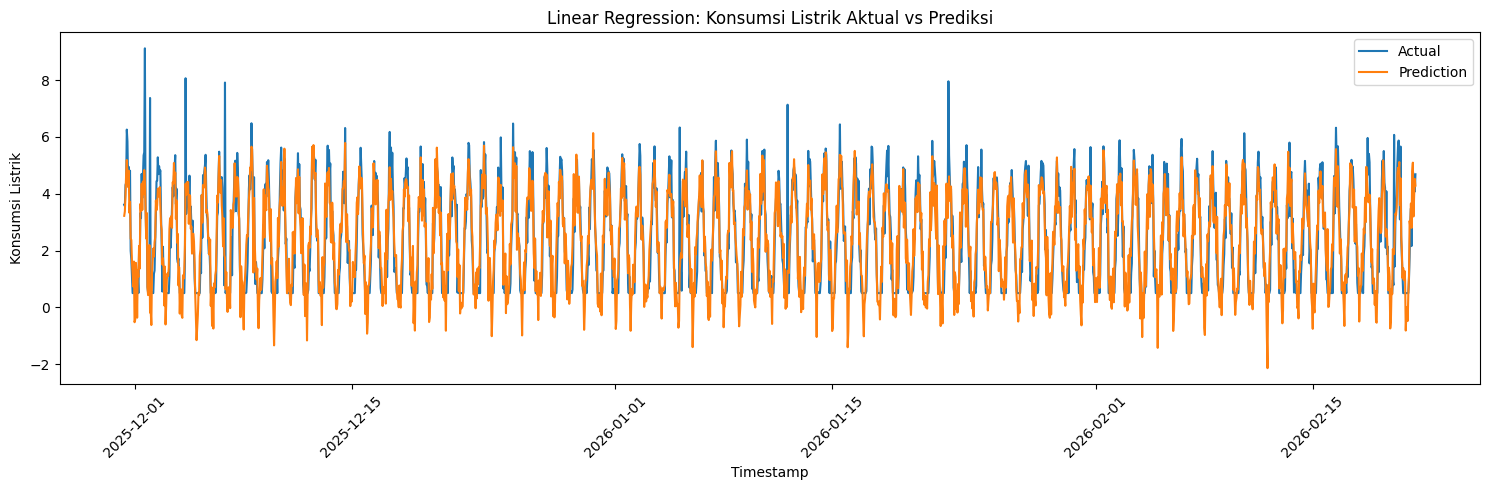

In [16]:
linear_prediction = linear_model.predict(X_test)

plt.figure(figsize=(15, 5))

plt.plot(
    test_time,
    y_test.values,
    label='Actual'
)

plt.plot(
    test_time,
    linear_prediction,
    label='Prediction'
)

plt.title(
    'Linear Regression: '
    'Konsumsi Listrik Aktual vs Prediksi'
)
plt.xlabel('Timestamp')
plt.ylabel('Konsumsi Listrik')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Cell 17 — Visualisasi Decision Tree: aktual vs prediksi

Grafik ini menggunakan konsep yang sama dengan grafik Linear Regression, tetapi prediksi berasal dari **Decision Tree Regressor**.

Visualisasi dapat digunakan untuk melihat apakah Decision Tree mampu mengikuti perubahan pola konsumsi listrik dengan lebih baik dibandingkan model linear.


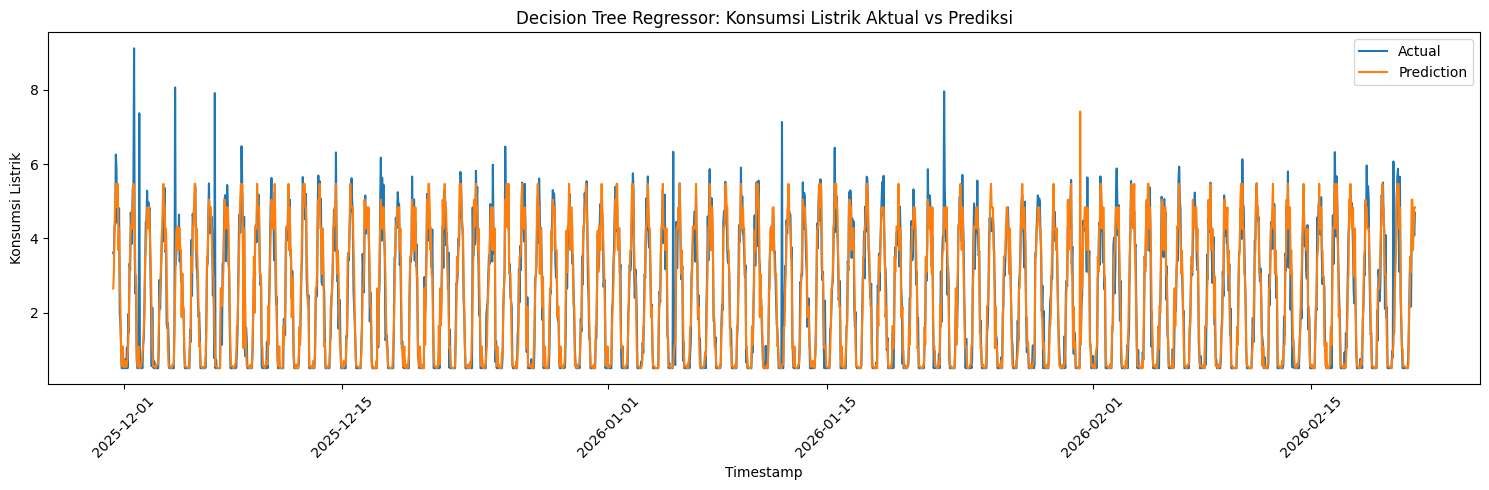

In [17]:
tree_prediction = tree_model.predict(X_test)

plt.figure(figsize=(15, 5))

plt.plot(
    test_time,
    y_test.values,
    label='Actual'
)

plt.plot(
    test_time,
    tree_prediction,
    label='Prediction'
)

plt.title(
    'Decision Tree Regressor: '
    'Konsumsi Listrik Aktual vs Prediksi'
)
plt.xlabel('Timestamp')
plt.ylabel('Konsumsi Listrik')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Cell 18 — Menampilkan kesimpulan berdasarkan hasil model

Cell terakhir menyusun ringkasan hasil secara otomatis berdasarkan nilai evaluasi yang diperoleh.

Pada dataset ini, Decision Tree diharapkan menghasilkan error test yang lebih rendah dan R² test yang lebih tinggi daripada Linear Regression. Kesimpulan juga menampilkan gap R² train-test untuk membantu menjelaskan apakah terdapat indikasi overfitting.


In [18]:
print("KESIMPULAN")
print("=" * 70)

print(
    f"Linear Regression menghasilkan Test MAE = "
    f"{linear_test['MAE']:.4f}, Test RMSE = "
    f"{linear_test['RMSE']:.4f}, dan Test R² = "
    f"{linear_test['R2']:.4f}."
)

print(
    f"Decision Tree menghasilkan Test MAE = "
    f"{tree_test['MAE']:.4f}, Test RMSE = "
    f"{tree_test['RMSE']:.4f}, dan Test R² = "
    f"{tree_test['R2']:.4f}."
)

if tree_test['R2'] > linear_test['R2']:
    print(
        "\nPada konfigurasi yang diuji, Decision Tree Regressor "
        "memberikan performa prediksi yang lebih baik karena "
        "memiliki R² test lebih tinggi."
    )
else:
    print(
        "\nPada konfigurasi yang diuji, Linear Regression "
        "memberikan R² test lebih tinggi."
    )

print(
    f"\nGap R² train-test Linear Regression = "
    f"{linear_r2_gap:.4f}."
)
print(
    f"Gap R² train-test Decision Tree = "
    f"{tree_r2_gap:.4f}."
)

print(
    "\nGap train-test yang relatif kecil menunjukkan bahwa "
    "kedua model tidak memperlihatkan indikasi overfitting "
    "yang kuat pada pembagian data ini."
)

KESIMPULAN
Linear Regression menghasilkan Test MAE = 0.5836, Test RMSE = 0.7731, dan Test R² = 0.8088.
Decision Tree menghasilkan Test MAE = 0.3435, Test RMSE = 0.5986, dan Test R² = 0.8854.

Pada konfigurasi yang diuji, Decision Tree Regressor memberikan performa prediksi yang lebih baik karena memiliki R² test lebih tinggi.

Gap R² train-test Linear Regression = -0.0113.
Gap R² train-test Decision Tree = 0.0130.

Gap train-test yang relatif kecil menunjukkan bahwa kedua model tidak memperlihatkan indikasi overfitting yang kuat pada pembagian data ini.
